In [1]:
import cv2
import matplotlib.pyplot as plt

  RGB TO CMY

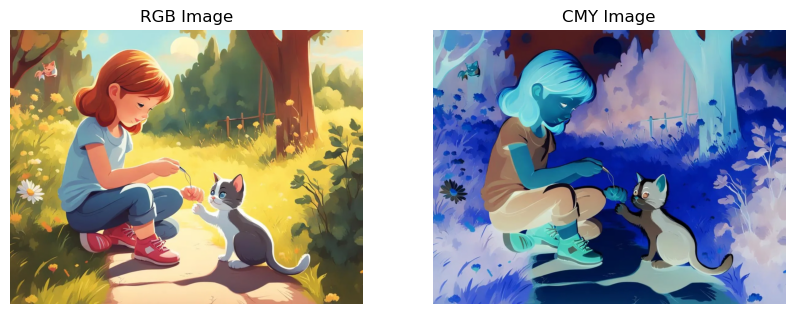

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image in RGB format (OpenCV loads images in BGR by default)
image = cv2.imread('nature.webp')

# Convert BGR to RGB (OpenCV loads images in BGR, so we need to swap channels)
rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert RGB to CMY
cmy_image = 255 - rgb_image

# Set up the figure for displaying both images
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Display the RGB image
axs[0].imshow(rgb_image)
axs[0].set_title('RGB Image')
axs[0].axis('off')

# Display the CMY image
axs[1].imshow(cmy_image)
axs[1].set_title('CMY Image')
axs[1].axis('off')

# Show the images
plt.show()

RGB TO HSV


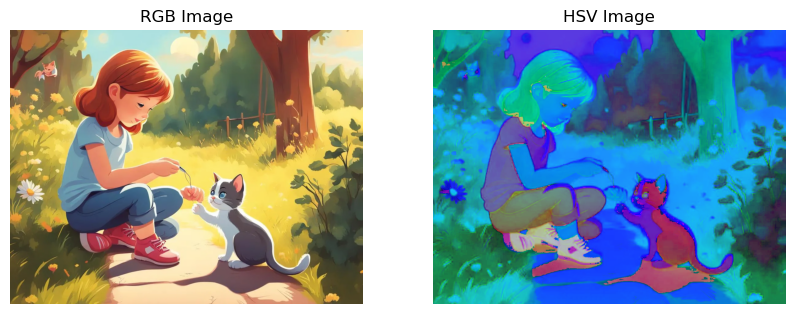

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image in RGB format (OpenCV loads images in BGR by default)
image = cv2.imread('nature.webp')

# Convert BGR to RGB (OpenCV loads images in BGR, so we need to swap channels)
rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert RGB to HSV
hsv_image = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2HSV)

# Set up the figure for displaying both images
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Display the RGB image
axs[0].imshow(rgb_image)
axs[0].set_title('RGB Image')
axs[0].axis('off')

# Display the HSV image
axs[1].imshow(hsv_image)
axs[1].set_title('HSV Image')
axs[1].axis('off')

# Show the images
plt.show()

rgb split

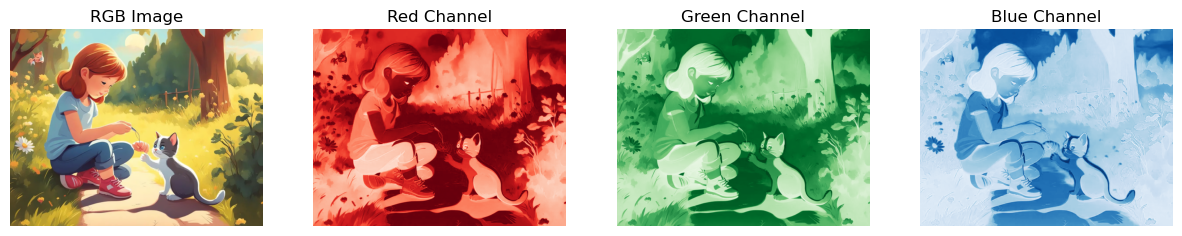

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image in RGB format (OpenCV loads images in BGR by default)
image = cv2.imread('nature.webp')

# Convert BGR to RGB
rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Split the image into its individual RGB channels
r, g, b = cv2.split(rgb_image)

# Set up the figure for displaying the RGB channels
fig, axs = plt.subplots(1, 4, figsize=(15, 5))

# Display the original RGB image
axs[0].imshow(rgb_image)
axs[0].set_title('RGB Image')
axs[0].axis('off')

# Display the Red channel
axs[1].imshow(r, cmap='Reds')
axs[1].set_title('Red Channel')
axs[1].axis('off')

# Display the Green channel
axs[2].imshow(g, cmap='Greens')
axs[2].set_title('Green Channel')
axs[2].axis('off')

# Display the Blue channel
axs[3].imshow(b, cmap='Blues')
axs[3].set_title('Blue Channel')
axs[3].axis('off')

# Show the images
plt.show()

cmy split

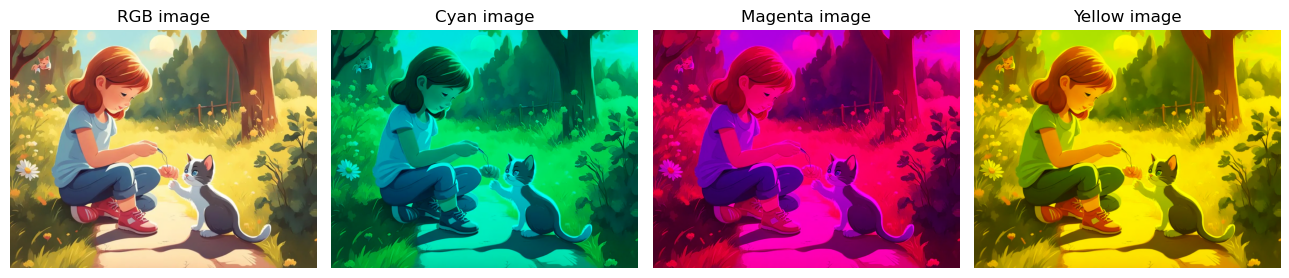

In [9]:
img_rgb = cv2.cvtColor(cv2.imread('nature.webp'),cv2.COLOR_BGR2RGB)

plt.figure(figsize=(13,5))

def cmy(i, j, k, l):
    cmy = img_rgb.copy()
    if i is not None:
        cmy[:, :, i] = 0        
    plt.subplot(1, 4, l)
    plt.imshow(cmy)
    plt.title(f"{k} image")
    plt.axis('off')

cmy(None, img_rgb, 'RGB', 1)
cmy(0, img_rgb, 'Cyan', 2)
cmy(1, img_rgb, 'Magenta', 3)
cmy(2, img_rgb, 'Yellow', 4)

plt.tight_layout()
plt.show()

rgb to ycbcr split

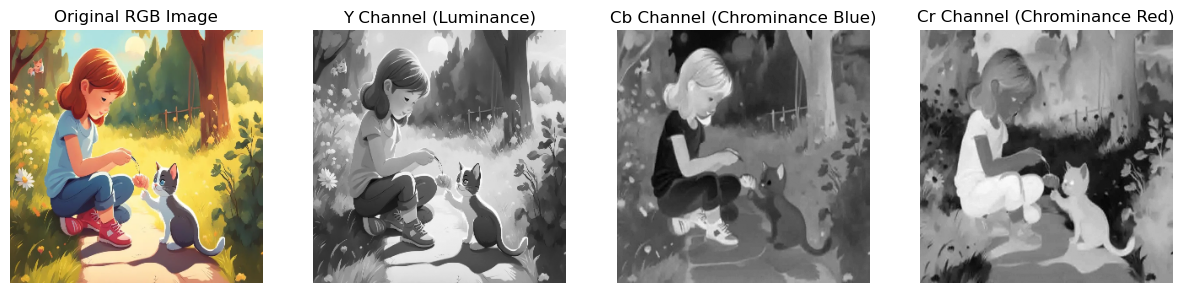

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the original RGB image
image = cv2.imread('nature.webp')  # Replace with your image path
image = cv2.resize(image, (300, 300))  # Resize for quicker display

# Convert the image from BGR to RGB (OpenCV loads in BGR by default)
rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert the RGB image to YCbCr color space
ycbcr_image = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2YCrCb)

# Split the YCbCr image into Y, Cb, and Cr channels
Y, Cb, Cr = cv2.split(ycbcr_image)

# Display the RGB and YCbCr channels using matplotlib
plt.figure(figsize=(15, 5))

# Display the original RGB image
plt.subplot(1, 4, 1)
plt.imshow(rgb_image)
plt.title('Original RGB Image')
plt.axis('off')

# Display the Y channel (luminance)
plt.subplot(1, 4, 2)
plt.imshow(Y, cmap='gray')
plt.title('Y Channel (Luminance)')
plt.axis('off')

# Display the Cb channel (blue chrominance)
plt.subplot(1, 4, 3)
plt.imshow(Cb, cmap='gray')
plt.title('Cb Channel (Chrominance Blue)')
plt.axis('off')

# Display the Cr channel (red chrominance)
plt.subplot(1, 4, 4)
plt.imshow(Cr, cmap='gray')
plt.title('Cr Channel (Chrominance Red)')
plt.axis('off')

plt.show()


 to extract dominant colours of image

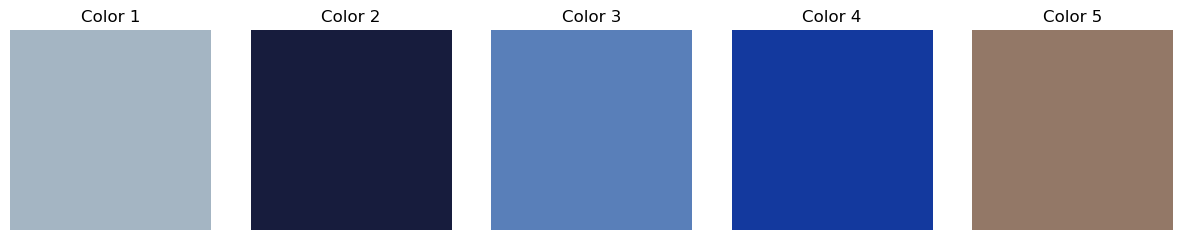

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Load the image
image = cv2.imread('nature.webp')

# Convert the image to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert the RGB image to CMY
image_cmy = 1 - image_rgb / 255.0

# Reshape the image to a 2D array of pixels
pixels = image_cmy.reshape(-1, 3)

# Perform K-means clustering to find the dominant colors
num_clusters = 5
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(pixels)

# Get the cluster centers (dominant colors)
dominant_colors = kmeans.cluster_centers_

# Convert the dominant colors to the range [0, 255]
dominant_colors = (dominant_colors * 255).astype(int)

# Plot the dominant colors
fig, ax = plt.subplots(1, num_clusters, figsize=(15, 5))
for i in range(num_clusters):
    color = dominant_colors[i].reshape(1, 1, 3)
    ax[i].imshow(color)
    ax[i].axis('off')
    ax[i].set_title(f'Color {i+1}')

plt.show()


In [7]:
!pip install scikit-learn

 to extract cyan,magenta,yellow from cmy model

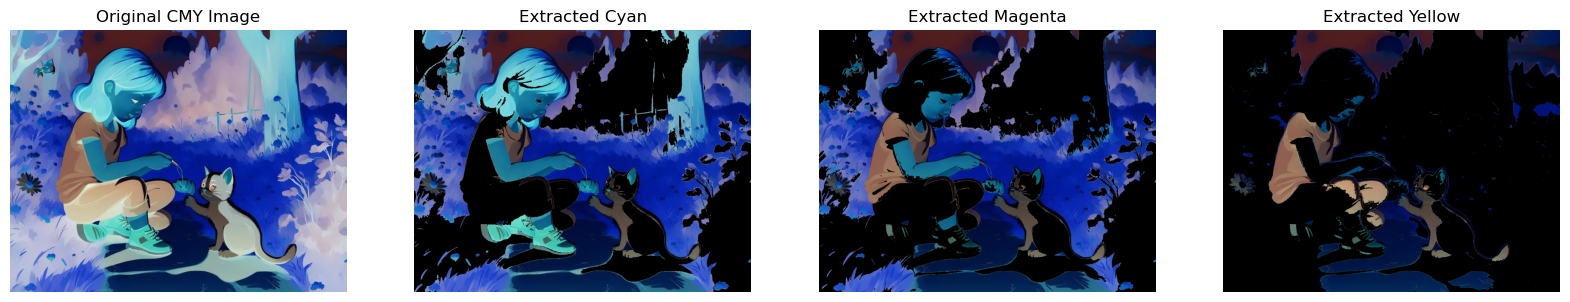

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image = cv2.imread('nature.webp')

# Convert the image to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert the RGB image to CMY
image_cmy = 1 - image_rgb / 255.0

# Define the lower and upper bounds for each CMY channel
lower_bound_c = np.array([0.0, 0.0, 0.0])  # Example lower bound for Cyan
upper_bound_c = np.array([0.5, 1.0, 1.0])  # Example upper bound for Cyan

lower_bound_m = np.array([0.0, 0.0, 0.0])  # Example lower bound for Magenta
upper_bound_m = np.array([1.0, 0.5, 1.0])  # Example upper bound for Magenta

lower_bound_y = np.array([0.0, 0.0, 0.0])  # Example lower bound for Yellow
upper_bound_y = np.array([1.0, 1.0, 0.5])  # Example upper bound for Yellow

# Create masks for each color range
mask_c = cv2.inRange(image_cmy, lower_bound_c, upper_bound_c)
mask_m = cv2.inRange(image_cmy, lower_bound_m, upper_bound_m)
mask_y = cv2.inRange(image_cmy, lower_bound_y, upper_bound_y)

# Extract the colors using the masks
extracted_c = cv2.bitwise_and(image_cmy, image_cmy, mask=mask_c)
extracted_m = cv2.bitwise_and(image_cmy, image_cmy, mask=mask_m)
extracted_y = cv2.bitwise_and(image_cmy, image_cmy, mask=mask_y)

# Display the original CMY image and the extracted colors
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(image_cmy)
axes[0].set_title('Original CMY Image')
axes[0].axis('off')

axes[1].imshow(extracted_c)
axes[1].set_title('Extracted Cyan')
axes[1].axis('off')

axes[2].imshow(extracted_m)
axes[2].set_title('Extracted Magenta')
axes[2].axis('off')

axes[3].imshow(extracted_y)
axes[3].set_title('Extracted Yellow')
axes[3].axis('off')

plt.show()


TO EXTRACT RED,BLUE.YELLOW FROM RGB MODEL

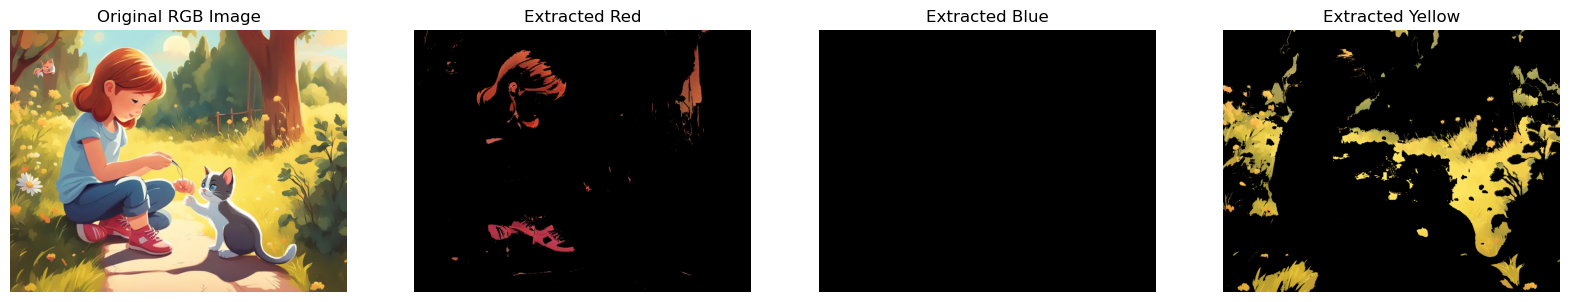

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image = cv2.imread('nature.webp')

# Convert the image to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Define lower and upper bounds for each color in RGB
# Red color range
lower_bound_red = np.array([150, 0, 0])
upper_bound_red = np.array([255, 100, 100])

# Blue color range
lower_bound_blue = np.array([0, 0, 150])
upper_bound_blue = np.array([100, 100, 255])

# Yellow color range
lower_bound_yellow = np.array([150, 150, 0])
upper_bound_yellow = np.array([255, 255, 100])

# Create masks for each color range
mask_red = cv2.inRange(image_rgb, lower_bound_red, upper_bound_red)
mask_blue = cv2.inRange(image_rgb, lower_bound_blue, upper_bound_blue)
mask_yellow = cv2.inRange(image_rgb, lower_bound_yellow, upper_bound_yellow)

# Extract the colors using the masks
extracted_red = cv2.bitwise_and(image_rgb, image_rgb, mask=mask_red)
extracted_blue = cv2.bitwise_and(image_rgb, image_rgb, mask=mask_blue)
extracted_yellow = cv2.bitwise_and(image_rgb, image_rgb, mask=mask_yellow)

# Display the original RGB image and the extracted colors
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(image_rgb)
axes[0].set_title('Original RGB Image')
axes[0].axis('off')

axes[1].imshow(extracted_red)
axes[1].set_title('Extracted Red')
axes[1].axis('off')

axes[2].imshow(extracted_blue)
axes[2].set_title('Extracted Blue')
axes[2].axis('off')

axes[3].imshow(extracted_yellow)
axes[3].set_title('Extracted Yellow')
axes[3].axis('off')

plt.show()


In [4]:
import cv2
import numpy as np

# Load the original image
original_image = cv2.imread('eiffel.jpg')

# Get image dimensions
height, width, channels = original_image.shape

# Create an empty array for the reflected image
reflected_image = np.zeros_like(original_image)

# Loop through each pixel and reflect horizontally
for y in range(height):
    for x in range(width):
        reflected_image[y, width - 1 - x] = original_image[y, x]

# Display both the original and reflected image using OpenCV
cv2.imshow('Original Image', original_image)
cv2.imshow('Reflected Image', reflected_image)

# Wait for a key press and close the image windows
cv2.waitKey(0)
cv2.destroyAllWindows()
